In [18]:
import sys
sys.path.append("..")

from src.data_loader import load_data, split_data
from pathlib import Path
import polars as pl
from src.models.regressor import build_regressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
import joblib
import matplotlib.pyplot as plt

from src.config import load_config
cfg = load_config(path=Path("../config.yaml"))

In [19]:
data = load_data(Path(f"../{cfg.paths.data_dir}"))

In [22]:
train_data, test_data = split_data(data, split_after_batch=6)

print(train_data.group_by("label").agg(pl.col("concentration").min().alias("conc_min"), pl.col("concentration").max().alias("conc_max")))

results = {}

for k, v in cfg.data.gas_labels.items():
    X_train= train_data.filter(pl.col("label") == k).select(pl.exclude("label", "concentration", "batch_id")).to_numpy()
    y_train = train_data.filter(pl.col("label") == k).select("concentration").to_numpy()

    X_test = test_data.filter(pl.col("label") == k).select(pl.exclude("label", "concentration", "batch_id")).to_numpy()
    y_test = test_data.filter(pl.col("label") == k).select("concentration").to_numpy()

    model = build_regressor()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results[v] = {"rmse": rmse, "mae": mae}

    Path(f"../{cfg.paths.models_dir}").mkdir(parents=True, exist_ok=True)
    joblib.dump(model, f"../{cfg.paths.models_dir}/regressor_{v}.pkl")

shape: (6, 3)
┌───────┬──────────┬──────────┐
│ label ┆ conc_min ┆ conc_max │
│ ---   ┆ ---      ┆ ---      │
│ i64   ┆ f64      ┆ f64      │
╞═══════╪══════════╪══════════╡
│ 5     ┆ 12.0     ┆ 500.0    │
│ 6     ┆ 5.0      ┆ 100.0    │
│ 1     ┆ 10.0     ┆ 600.0    │
│ 3     ┆ 50.0     ┆ 1000.0   │
│ 4     ┆ 10.0     ┆ 300.0    │
│ 2     ┆ 10.0     ┆ 300.0    │
└───────┴──────────┴──────────┘


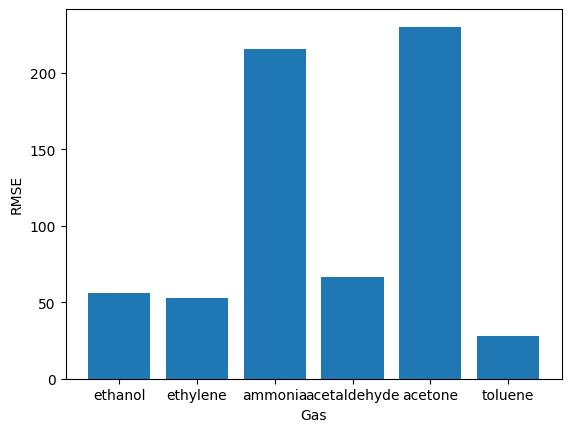

In [23]:
names = results.keys()
rmse_values = [v["rmse"] for v in results.values()]

plt.bar(names, rmse_values)
plt.xlabel("Gas")
plt.ylabel("RMSE")
plt.savefig(f"../{cfg.paths.results_dir}/concentration_rmse.png")
plt.show()